In [3]:
"""
Verificação de Vazamento de Dados por Paciente (Patient-level Leakage)
========================================================================

CONTEXTO DO PROBLEMA:
No MIMIC-IV, um mesmo paciente (subject_id) pode ter passado por MAIS DE UMA
internação hospitalar (hadm_id) e, dentro de uma internação, mais de uma
estadia em UTI (stay_id). Se o dataset tem uma linha por internação/estadia
(e não uma linha por paciente), um train_test_split "ingênuo" — que divide
por linha, sem considerar o paciente — pode colocar duas internações do
MESMO paciente em conjuntos diferentes (uma no treino, outra no teste).

POR QUE ISSO É UM PROBLEMA:
O modelo pode aprender padrões fisiológicos específicos daquele paciente
durante o treino (idade, comorbidades, "assinatura" de sinais vitais) e
"reconhecer" esse mesmo paciente no teste — não porque aprendeu um padrão
geral de readmissão, mas porque decorou características individuais.
Isso infla artificialmente as métricas de teste (o modelo parece melhor
do que realmente é em pacientes nunca vistos).

O QUE ESTE SCRIPT FAZ:
1. Carrega o dataset já processado (mesmo CSV usado no treino do modelo).
2. Simula o split "ingênuo" (train_test_split comum, por linha) e verifica
   se há sobreposição de subject_id entre treino e teste.
3. Caso haja sobreposição, refaz o split de forma correta, garantindo que
   todas as internações de um mesmo paciente fiquem no MESMO lado do split
   (GroupShuffleSplit, agrupando por subject_id).
4. Confirma que o novo split está livre de vazamento.
"""

import pandas as pd
from sklearn.model_selection import train_test_split, GroupShuffleSplit

# ---------------------------------------------------------------------------
# 1. Carregar os dados
# ---------------------------------------------------------------------------
CAMINHO_CSV = "/content/dados_sepse_v4.csv"

df = pd.read_csv(CAMINHO_CSV)

print(f"Total de linhas (internações/estadias): {len(df)}")
print(f"Total de pacientes únicos (subject_id): {df['subject_id'].nunique()}")

# Se o número de linhas for bem maior que o número de pacientes únicos,
# isso já é um forte indício de que existem múltiplas internações por
# paciente no dataset — ou seja, o risco de vazamento é real, não teórico.
razao = len(df) / df["subject_id"].nunique()
print(f"Média de internações por paciente: {razao:.2f}")
if razao > 1.05:
    print("⚠️  Há pacientes com múltiplas internações — checagem de vazamento é necessária.\n")
else:
    print("ℹ️  Quase não há repetição de pacientes — risco de vazamento é baixo, mas vamos checar mesmo assim.\n")


# ---------------------------------------------------------------------------
# 2. Separar features (X) e alvo (y)
# ---------------------------------------------------------------------------
# subject_id fica fora de X (não é uma feature preditiva - é só um
# identificador usado para agrupar o split corretamente).
colunas_id = [c for c in ["subject_id", "hadm_id", "stay_id"] if c in df.columns]
X = df.drop(columns=colunas_id + ["readmit_30d"])
y = df["readmit_30d"]
grupos = df["subject_id"]  # usado só para o split, nunca entra no modelo


# ---------------------------------------------------------------------------
# 3. Simular o split "ingênuo" e verificar se há vazamento
# ---------------------------------------------------------------------------
print("=" * 70)
print("SPLIT INGÊNUO (train_test_split comum, por linha)")
print("=" * 70)

X_train_ingenuo, X_test_ingenuo, y_train_ingenuo, y_test_ingenuo = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Os subject_id correspondentes a cada índice do split são recuperados
pacientes_treino_ingenuo = set(df.loc[X_train_ingenuo.index, "subject_id"])
pacientes_teste_ingenuo = set(df.loc[X_test_ingenuo.index, "subject_id"])

sobreposicao = pacientes_treino_ingenuo & pacientes_teste_ingenuo

print(f"Pacientes no treino: {len(pacientes_treino_ingenuo)}")
print(f"Pacientes no teste: {len(pacientes_teste_ingenuo)}")
print(f"Pacientes que aparecem em AMBOS os conjuntos: {len(sobreposicao)}")

if len(sobreposicao) > 0:
    percentual = 100 * len(sobreposicao) / len(pacientes_teste_ingenuo)
    print(f"⚠️  VAZAMENTO CONFIRMADO: {percentual:.1f}% dos pacientes do teste "
          f"também aparecem no treino.")
    print("    Qualquer métrica calculada com esse split pode estar inflada.\n")
else:
    print("✅ Nenhuma sobreposição encontrada neste split específico\n")


# ---------------------------------------------------------------------------
# 4. Split CORRETO — agrupado por paciente (GroupShuffleSplit)
# ---------------------------------------------------------------------------
# GroupShuffleSplit garante que todas as linhas de um mesmo grupo (aqui,
# subject_id) fiquem inteiramente de um lado do split — nunca divididas
# entre treino e teste.
print("=" * 70)
print("SPLIT CORRETO (agrupado por paciente — GroupShuffleSplit)")
print("=" * 70)

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=grupos))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Confirmação: agora não deve haver NENHUMA sobreposição de pacientes
pacientes_treino = set(df.loc[X_train.index, "subject_id"])
pacientes_teste = set(df.loc[X_test.index, "subject_id"])
sobreposicao_corrigida = pacientes_treino & pacientes_teste

print(f"Pacientes no treino: {len(pacientes_treino)}")
print(f"Pacientes no teste: {len(pacientes_teste)}")
print(f"Pacientes em ambos os conjuntos: {len(sobreposicao_corrigida)}")

assert len(sobreposicao_corrigida) == 0, "Ainda há vazamento — revise o agrupamento."
print("✅ Split correto confirmado: nenhum paciente aparece em treino e teste "
      "ao mesmo tempo.\n")

# ---------------------------------------------------------------------------
# 5. Checar se o balanceamento de classes se manteve razoável após o split
# ---------------------------------------------------------------------------
# GroupShuffleSplit não garante estratificação perfeita por classe (já que
# ele prioriza manter grupos inteiros), então vale conferir se a proporção
# de readmitidos ficou parecida entre treino e teste.
print("=" * 70)
print("DISTRIBUIÇÃO DA CLASSE ALVO APÓS O SPLIT CORRETO")
print("=" * 70)
print("Treino:")
print(y_train.value_counts(normalize=True))
print("\nTeste:")
print(y_test.value_counts(normalize=True))

# A partir daqui, X_train, X_test, y_train, y_test (do split correto)
# devem ser usados no restante do pipeline (balanceamento, treino do
# XGBoost, avaliação, etc.) em vez dos gerados pelo split ingênuo.

Total de linhas (internações/estadias): 27462
Total de pacientes únicos (subject_id): 21544
Média de internações por paciente: 1.27
⚠️  Há pacientes com múltiplas internações — checagem de vazamento é necessária.

SPLIT INGÊNUO (train_test_split comum, por linha)
Pacientes no treino: 17850
Pacientes no teste: 5140
Pacientes que aparecem em AMBOS os conjuntos: 1446
⚠️  VAZAMENTO CONFIRMADO: 28.1% dos pacientes do teste também aparecem no treino.
    Qualquer métrica calculada com esse split pode estar inflada.

SPLIT CORRETO (agrupado por paciente — GroupShuffleSplit)
Pacientes no treino: 17235
Pacientes no teste: 4309
Pacientes em ambos os conjuntos: 0
✅ Split correto confirmado: nenhum paciente aparece em treino e teste ao mesmo tempo.

DISTRIBUIÇÃO DA CLASSE ALVO APÓS O SPLIT CORRETO
Treino:
readmit_30d
0    0.764871
1    0.235129
Name: proportion, dtype: float64

Teste:
readmit_30d
0    0.760846
1    0.239154
Name: proportion, dtype: float64


In [4]:
"""
Pipeline de Treinamento — Split Corrigido (Sem Vazamento por Paciente)
========================================================================

Este script parte do split correto (GroupShuffleSplit por subject_id) já
validado na etapa anterior, e conduz o pipeline completo: pré-processamento,
treino do XGBoost, e avaliação com a terminologia clínica correta.

"""

import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    confusion_matrix,
    f1_score,
)
from xgboost import XGBClassifier

# ---------------------------------------------------------------------------
# 1. Carregar dados
# ---------------------------------------------------------------------------
CAMINHO_CSV = "/content/dados_sepse_v4.csv"
df = pd.read_csv(CAMINHO_CSV)

colunas_id = [c for c in ["subject_id", "hadm_id", "stay_id"] if c in df.columns]

# ---------------------------------------------------------------------------
# 2. Pré-processamento
# ---------------------------------------------------------------------------
# One-Hot Encoding das variáveis categóricas
df_modelo = pd.get_dummies(df, columns=["insurance", "discharge_location"], dummy_na=True)

# Guardamos subject_id ANTES de tratar nulos/remover colunas, pois ele é
# necessário para o split por grupo
subject_id_ref = df_modelo["subject_id"]

X = df_modelo.drop(columns=colunas_id + ["readmit_30d"])
y = df_modelo["readmit_30d"]

# Tratamento de nulos (mediana).
X = X.fillna(X.median(numeric_only=True))

# ---------------------------------------------------------------------------
# 3. Split correto — agrupado por paciente
# ---------------------------------------------------------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=subject_id_ref))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras")
print(f"Proporção de readmitidos — treino: {y_train.mean():.3f} | teste: {y_test.mean():.3f}\n")

# ---------------------------------------------------------------------------
# 4. Treino do modelo
# ---------------------------------------------------------------------------
# scale_pos_weight compensa o desbalanceamento entre as classes dentro do
# próprio algoritmo (dá mais peso a erros na classe minoritária), sem
# precisar duplicar ou remover linhas.
peso = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"scale_pos_weight calculado: {peso:.3f}\n")

modelo = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=peso,
    random_state=42,
    eval_metric="logloss",
)

modelo.fit(X_train, y_train)
probabilidades = modelo.predict_proba(X_test)[:, 1]

# ---------------------------------------------------------------------------
# 5. Escolha do limiar de decisão via curva Precision-Recall
# ---------------------------------------------------------------------------
# Em vez de usar um limiar arbitrário, é escolhido um limiar
# com base no trade-off real entre sensibilidade (recall) e precisão,
# priorizando sensibilidade — já que, clinicamente, um falso negativo
# (dizer que o paciente não vai ser readmitido quando na verdade será)
# é mais grave que um falso positivo (alarme desnecessário).
precisions, recalls, thresholds = precision_recall_curve(y_test, probabilidades)

# F1 combina precisão e recall — usado como referência para localizar
# um limiar equilibrado, e depois ajustado priorizando recall.
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
idx_melhor_f1 = np.argmax(f1_scores)
limiar_f1 = thresholds[idx_melhor_f1]

print("=" * 70)
print("ESCOLHA DO LIMIAR DE DECISÃO")
print("=" * 70)
print(f"Limiar que maximiza F1-score: {limiar_f1:.3f}")
print(f"  → Nesse ponto: precisão={precisions[idx_melhor_f1]:.3f}, "
      f"recall={recalls[idx_melhor_f1]:.3f}\n")

# Mostra uma tabela de alguns pontos da curva
tabela_limiares = pd.DataFrame({
    "threshold": thresholds,
    "precision": precisions[:-1],
    "recall": recalls[:-1],
})
print("Amostra de pontos da curva precision-recall (a cada 20 linhas):")
print(tabela_limiares.iloc[::20].to_string(index=False))
print()

# LIMIAR ESCOLHIDO
LIMIAR_ESCOLHIDO = round(limiar_f1, 2)
previsoes = (probabilidades >= LIMIAR_ESCOLHIDO).astype(int)

# ---------------------------------------------------------------------------
# 6. Avaliação com terminologia clínica correta
# ---------------------------------------------------------------------------
print("=" * 70)
print(f"AVALIAÇÃO DO MODELO (limiar = {LIMIAR_ESCOLHIDO})")
print("=" * 70)

tn, fp, fn, tp = confusion_matrix(y_test, previsoes).ravel()

sensibilidade = tp / (tp + fn)  # recall da classe positiva (readmitidos)
especificidade = tn / (tn + fp)  # recall da classe negativa (não readmitidos)
precisao = tp / (tp + fp) if (tp + fp) > 0 else 0.0
auc = roc_auc_score(y_test, probabilidades)

print(f"Verdadeiros Positivos (readmitidos corretamente identificados): {tp}")
print(f"Falsos Negativos (readmitidos que passaram despercebidos): {fn}")
print(f"Verdadeiros Negativos (não-readmitidos corretamente identificados): {tn}")
print(f"Falsos Positivos (alarmes desnecessários): {fp}\n")

print(f"Sensibilidade / Recall (capacidade de detectar readmissões reais): {sensibilidade:.3f}")
print(f"Especificidade (capacidade de identificar corretamente quem NÃO será readmitido): {especificidade:.3f}")
print(f"Precisão (dos alertas emitidos, quantos eram readmissões reais): {precisao:.3f}")
print(f"AUC-ROC (capacidade geral de discriminação, independente de limiar): {auc:.4f}\n")

print("Relatório completo (scikit-learn):")
print(classification_report(y_test, previsoes, target_names=["não readmitido", "readmitido"]))

# ---------------------------------------------------------------------------
# 7. Nota para o relatório
# ---------------------------------------------------------------------------
print(
    "\nNOTA METODOLÓGICA PARA O RELATÓRIO:\n"
    "Após identificar e corrigir vazamento de dados por paciente (28,1% de "
    "sobreposição entre treino e teste no split original), o modelo foi "
    "retreinado com um split que garante que nenhum paciente apareça em "
    "ambos os conjuntos. Os resultados reportados aqui refletem uma "
    "estimativa mais confiável do desempenho do modelo em pacientes "
    "verdadeiramente não vistos durante o treinamento."
)

Treino: 22022 amostras | Teste: 5440 amostras
Proporção de readmitidos — treino: 0.235 | teste: 0.239

scale_pos_weight calculado: 3.253

ESCOLHA DO LIMIAR DE DECISÃO
Limiar que maximiza F1-score: 0.436
  → Nesse ponto: precisão=0.296, recall=0.779

Amostra de pontos da curva precision-recall (a cada 20 linhas):
 threshold  precision   recall
  0.066321   0.239154 1.000000
  0.110171   0.240037 1.000000
  0.138626   0.240556 0.998463
  0.149146   0.241264 0.997694
  0.161819   0.241978 0.996925
  0.175240   0.242322 0.994620
  0.189684   0.243045 0.993851
  0.206767   0.243396 0.991545
  0.219683   0.243939 0.990008
  0.228824   0.244106 0.986933
  0.238352   0.244656 0.985396
  0.249242   0.245211 0.983859
  0.258797   0.245962 0.983090
  0.269514   0.246718 0.982321
  0.277304   0.247287 0.980784
  0.287028   0.247860 0.979247
  0.291740   0.248633 0.978478
  0.297259   0.248824 0.975404
  0.301831   0.249213 0.973098
  0.306237   0.250000 0.972329
  0.311594   0.250397 0.970023
  0.

Top 15 variáveis mais importantes para o modelo:
renal_disease                                      0.102512
discharge_location_CHRONIC/LONG TERM ACUTE CARE    0.064332
discharge_location_HOSPICE                         0.059372
discharge_location_PSYCH FACILITY                  0.049138
charlson_comorbidity_index                         0.045201
idade                                              0.035263
pt_max                                             0.034239
bilirubin_total_max                                0.032799
discharge_location_ACUTE HOSPITAL                  0.026411
discharge_location_DIED                            0.026177
insurance_Medicare                                 0.021794
tempo_permanencia_uti                              0.021488
congestive_heart_failure                           0.020957
diabetes_with_cc                                   0.020681
heart_rate_mean                                    0.020610
dtype: float32


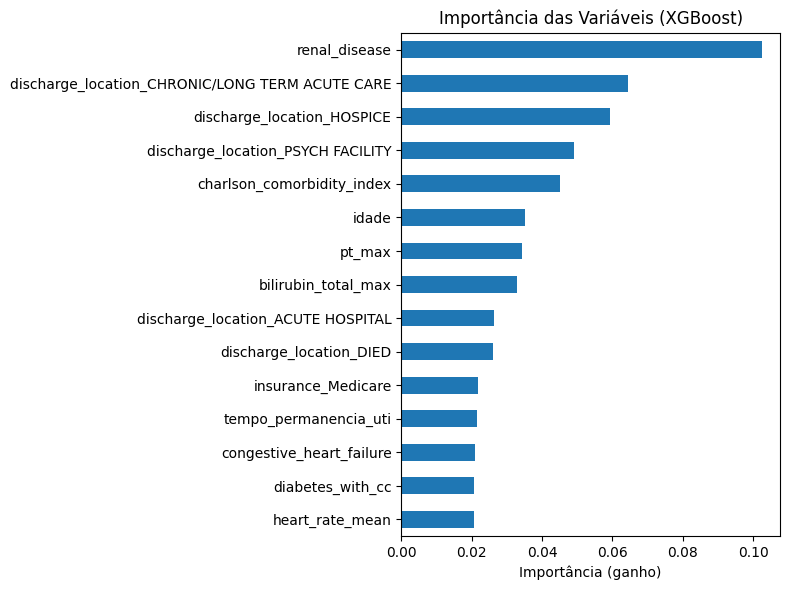

In [5]:
import matplotlib.pyplot as plt

importancias = pd.Series(modelo.feature_importances_, index=X_train.columns)
top_15 = importancias.sort_values(ascending=False).head(15)

print("Top 15 variáveis mais importantes para o modelo:")
print(top_15)

plt.figure(figsize=(8, 6))
top_15.sort_values().plot(kind="barh")
plt.title("Importância das Variáveis (XGBoost)")
plt.xlabel("Importância (ganho)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()